In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from xgboost import XGBRegressor

from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import TimeSeriesSplit

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score



In [2]:
df = pd.read_csv(r"C:\Users\ramya\OneDrive\Desktop\Stock Market prediction project\aapl_cleaned.csv")

In [3]:
df.head()

,Unnamed: 0,Date,Close,High,Low,Open,Volume,Daily_Return,MA20,MA50,Target
0,0,2015-03-16,27.758127,27.758127,27.296048,27.520423,143497200,0.011004,28.371493,26.537694,28.222433
1,1,2015-03-17,28.222433,28.284636,27.913639,27.969178,204092400,0.016727,28.362718,26.618291,28.540108
2,2,2015-03-18,28.540108,28.693394,28.073585,28.213541,261083600,0.011256,28.359940,26.718872,28.324614
3,3,2015-03-19,28.324614,28.713383,28.302399,28.602306,183238000,-0.007551,28.349388,26.815098,27.969172
4,4,2015-03-20,27.969172,28.524554,27.804778,28.491233,274780400,-0.012549,28.309401,26.897622,28.260189


In [4]:
df.columns

Index(['Unnamed: 0', 'Date', 'Close', 'High', 'Low', 'Open', 'Volume',
       'Daily_Return', 'MA20', 'MA50', 'Target'],
      dtype='str')

In [ ]:
# Remove the unwanted index column
df.drop(columns=["Unnamed: 0"], errors="ignore", inplace=True)
# Convert Date into datetime format
df["Date"] = pd.to_datetime(df["Date"])
# Sort the data from oldest to newest
df.sort_values("Date", inplace=True)
# Reset the row numbers
df.reset_index(drop=True, inplace=True)

In [6]:
df.columns

Index(['Date', 'Close', 'High', 'Low', 'Open', 'Volume', 'Daily_Return',
       'MA20', 'MA50', 'Target'],
      dtype='str')

In [ ]:
# Create the target as the next day's closing price
df["Target"] = df["Close"].shift(-1)

In [ ]:
# Create previous closing price features
df["Lag1"] = df["Close"].shift(1)
df["Lag2"] = df["Close"].shift(2)
df["Lag3"] = df["Close"].shift(3)
df["Lag5"] = df["Close"].shift(5)
df["Lag10"] = df["Close"].shift(10)

In [ ]:
# Calculate 10-day and 20-day exponential moving averages
df["EMA10"] = df["Close"].ewm(span=10,adjust=False).mean()

df["EMA20"] = df["Close"].ewm(span=20,adjust=False).mean()

In [ ]:
# Calculate the daily price change
delta = df["Close"].diff()
# Separate positive price changes
gain = delta.clip(lower=0)
# Separate negative price changes
loss = -delta.clip(upper=0)
# Calculate the average gain for 14 days
average_gain = gain.rolling(window=14).mean()
# Calculate the average loss for 14 days
average_loss = loss.rolling(window=14).mean()
# Calculate relative strength
rs = average_gain / average_loss
# Calculate RSI
df["RSI"] = 100 - (100 / (1 + rs))

In [ ]:
# Calculate 12-day and 26-day exponential moving averages
ema12 = df["Close"].ewm(span=12,adjust=False).mean()

ema26 = df["Close"].ewm(span=26,adjust=False).mean()
# Calculate MACD
df["MACD"] = ema12 - ema26
# Calculate the MACD signal line
df["Signal_Line"] = df["MACD"].ewm(span=9,adjust=False).mean()

In [ ]:
# Remove rows with missing values
df.dropna(inplace=True)
# Reset the row numbers
df.reset_index(drop=True,inplace=True)
# Check the final dataset size
print("Final dataset size:", df.shape)

Final dataset size: (2450, 20)


In [36]:
df.columns

Index(['Date', 'Close', 'High', 'Low', 'Open', 'Volume', 'Daily_Return',
       'MA20', 'MA50', 'Target', 'Lag1', 'Lag2', 'Lag3', 'Lag5', 'Lag10',
       'EMA10', 'EMA20', 'RSI', 'MACD', 'Signal_Line'],
      dtype='str')

In [ ]:
# Select the features used for XGBoost prediction
features = [
    "Open",
    "High",
    "Low",
    "Close",
    "Volume",
    "Daily_Return",
    "MA20",
    "MA50",
    "Lag1",
    "Lag2",
    "Lag3",
    "Lag5",
    "Lag10",
    "EMA10",
    "EMA20",
    "RSI",
    "MACD",
    "Signal_Line"
]
# Separate the input features and target
X = df[features]

y = df["Target"]

In [ ]:
# Use 80% of the earlier data for training
train_size = int(len(df) * 0.80)
# Create the training and testing features
X_train = X.iloc[:train_size]
X_test = X.iloc[train_size:]
# Create the training and testing targets
y_train = y.iloc[:train_size]
y_test = y.iloc[train_size:]

In [17]:
print("Training period:")
print(df["Date"].iloc[0],"to",df["Date"].iloc[train_size - 1])

print("Testing period:")
print(df["Date"].iloc[train_size],"to",df["Date"].iloc[-1])

Training period:
2015-04-06 00:00:00 to 2023-01-13 00:00:00
Testing period:
2023-01-17 00:00:00 to 2024-12-26 00:00:00


In [ ]:
#Check the highest price in the training target
print(f"Maximum training target:")
print(y_train.max())
# Check the price range in the test target
print(f"Test target range:")
print(y_test.min(), "to", y_test.max())

Maximum training target:
177.93972778320312
Test target range:
132.95352172851562 to 257.3755798339844


In [20]:
print("Training target range:")
print(round(y_train.min(), 2),"to",round(y_train.max(), 2))

print("Test target range:")
print(round(y_test.min(), 2),"to",round(y_test.max(), 2))

Training target range:
20.57 to 177.94
Test target range:
132.95 to 257.38


In [ ]:
# Create the baseline XGBoost model
baseline = XGBRegressor(

    objective="reg:squarederror",

    n_estimators=150,

    learning_rate=0.03,

    max_depth=3,

    subsample=0.8,

    colsample_bytree=0.8,

    random_state=42

)
# Train the baseline XGBoost model
baseline.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [ ]:
# Predict the next-day closing prices
baseline_prediction = baseline.predict(X_test)

In [23]:
mae = mean_absolute_error(y_test, baseline_prediction)

rmse = np.sqrt(mean_squared_error(y_test, baseline_prediction))

r2 = r2_score(y_test, baseline_prediction)

print("Baseline Results")

print("MAE :", round(mae,2))

print("RMSE :", round(rmse,2))

print("R2 :", round(r2,2))

Baseline Results
MAE : 22.09
RMSE : 31.79
R2 : -0.41


Hyperparameter tuning

In [ ]:
# Set different XGBoost parameters for tuning
param_grid = {

    "n_estimators":[200,300,400],

    "learning_rate":[0.01,0.05,0.1],

    "max_depth":[3,5,7],

    "subsample":[0.8,1],

    "colsample_bytree":[0.8,1]

}

In [ ]:
# Create 5 time-based splits for model tuning
tscv = TimeSeriesSplit(n_splits=5)

In [ ]:
# Use Grid Search to find the best XGBoost settings
grid = GridSearchCV(

    estimator=XGBRegressor(

        objective="reg:squarederror",

        random_state=42

    ),

    param_grid=param_grid,
    # Use time-series cross-validation
    cv=tscv,
    # Compare models using mean squared error
    scoring="neg_mean_squared_error",

    n_jobs=-1,

    verbose=2

)
# Start searching for the best parameters
grid.fit(X_train,y_train)


Fitting 5 folds for each of 108 candidates, totalling 540 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBRegressor(...ree=None, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'colsample_bytree': [0.8, 1], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 5, ...], 'n_estimators': [200, 300, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",TimeSeriesSpl...est_size=None)
,"verbose verbose: intControls the verbosity: the higher, the more messag

In [ ]:
# Display the best parameters found
print(grid.best_params_)

{'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 400, 'subsample': 0.8}


In [ ]:
# Save the best XGBoost model
best_model = grid.best_estimator_

In [ ]:
# Predict the test data using the tuned model
prediction = best_model.predict(X_test)

In [31]:
mae = mean_absolute_error(y_test,prediction)

rmse = np.sqrt(mean_squared_error(y_test,prediction))

r2 = r2_score(y_test,prediction)


print("MAE :",round(mae,2))

print("RMSE :",round(rmse,2))

print("R2 :",round(r2,2))

MAE : 23.07
RMSE : 32.63
R2 : -0.49


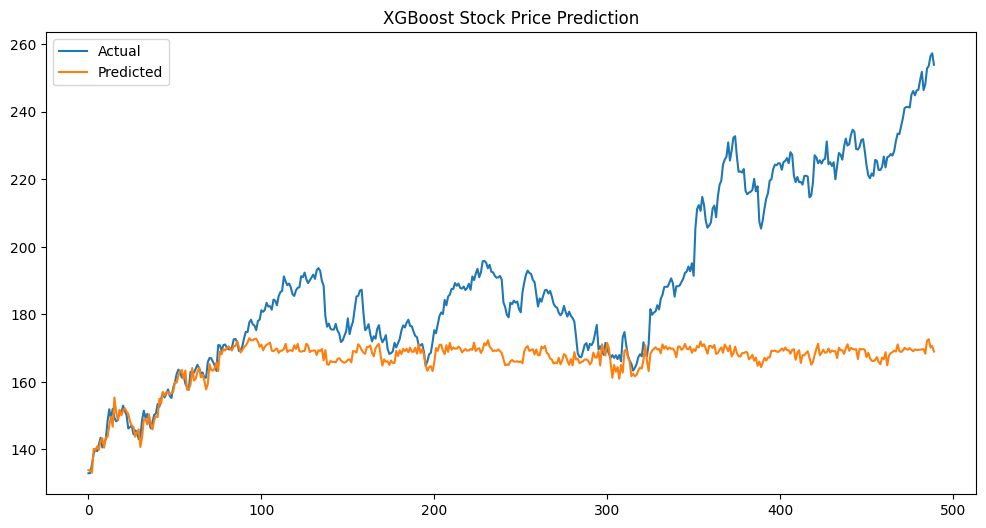

In [32]:
plt.figure(figsize=(12,6))

plt.plot(y_test.values,label="Actual")

plt.plot(prediction,label="Predicted")

plt.legend()

plt.title("XGBoost Stock Price Prediction")

plt.show()

         Feature  Importance
8           Lag1    0.283605
12         Lag10    0.263817
6           MA20    0.145082
2            Low    0.102009
1           High    0.073979
3          Close    0.063620
9           Lag2    0.044396
11          Lag5    0.018922
13         EMA10    0.001914
10          Lag3    0.000700
7           MA50    0.000643
0           Open    0.000553
14         EMA20    0.000520
17   Signal_Line    0.000055
5   Daily_Return    0.000055
15           RSI    0.000047
16          MACD    0.000045
4         Volume    0.000039


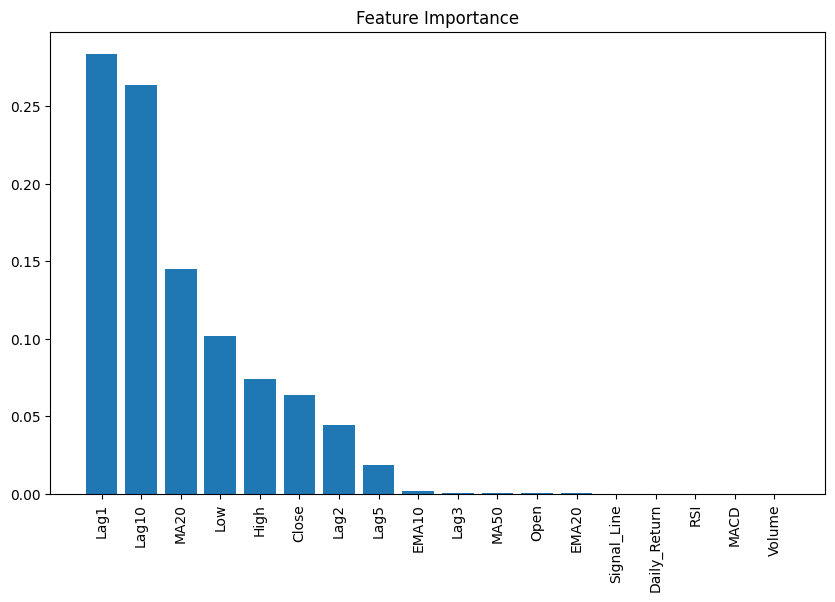

In [ ]:
# Check how important each feature was to the model
importance = pd.DataFrame({

    "Feature":features,

    "Importance":best_model.feature_importances_

})
# Sort features from most important to least important
importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance)

plt.figure(figsize=(10,6))

plt.bar(
    importance["Feature"],
    importance["Importance"]
)

plt.xticks(rotation=90)

plt.title("Feature Importance")

plt.show()

In [ ]:
# Compare the baseline and tuned XGBoost results

comparison = pd.DataFrame({

    "Model":["Baseline","Tuned"],

    "MAE":[

        mean_absolute_error(y_test,baseline_prediction),

        mean_absolute_error(y_test,prediction)

    ],

    "RMSE":[

        np.sqrt(mean_squared_error(y_test,baseline_prediction)),

        np.sqrt(mean_squared_error(y_test,prediction))

    ],

    "R2":[

        r2_score(y_test,baseline_prediction),

        r2_score(y_test,prediction)

    ]

})

print(comparison)

      Model        MAE       RMSE        R2
0  Baseline  22.092577  31.791800 -0.411999
1     Tuned  23.070508  32.628915 -0.487337
